# Running passim on a small corpus

This notebook runs the text-reuse detection software [passim](https://github.com/dasmiq/passim) on a small set of texts.

It is intended to enable anyone to run passim without having to install anything or to write any code. You just need to upload text files into Google colab and press the play buttons on each code block.

Feel free to make a copy of this notebook and adapt it for your needs.

To work with this notebook: download it, go to https://colab.research.google.com and upload it there. Good luck!

## Step 0. Initialize this notebook

This is a notebook that is intended to be used on [Google Colab](https://colab.research.google.com).

A notebook combines text blocks (instructions and explanations) and Python code blocks that can be executed online, without installing anything on your computer.

The code is hidden by default. You can show the code by clicking "show code" in a code block, and hide it when it's visible by right-clicking the code block and selecting "hide code" (or in the menu, choose `View > Show/hide code`).

You don't have to understand the code - you only have to execute the code by clicking the "play" button that appears besides a code cell when you hover over it.

Let's run the first code block (which creates a "texts" folder in this notebook). When the code has run, you'll see a message below the block.

If you run the same cell a second time, it will ask you whether to remove or keep the existing "texts" folder - so that you don't accidentally delete your texts.

In [ ]:
# @title Create the "texts" folder
import os

try:
  os.makedirs("texts", exist_ok=False)
except:
  print("The 'texts' folder already exists.")
  print("Do you want to delete its contents and start with a fresh folder?")
  print("Type 'Y' to empty the folder, or 'N' to keep the folder")
  r = input("(and confirm by pressing Enter): ")
  if "Y" in r.upper():
    os.removedirs("texts")
    os.makedirs("texts")


print("Done! Move to the next step.")

## Step 1. Prepare your texts.

Some remarks on the file names and structure of the text files you want to run passim on:
1. Texts should be in plain text files (not Word documents, pdfs or other formats). Give all the files the **extension ".txt"**; only files with this extension will be processed.
2. The filenames will become IDs in the text reuse data. Make sure you name the text files with clear, **unique filenames** so that you can easily identify the files by their ids later.
3. For file names, use a combinaton of unaccented Latin-script letters and numbers and **avoid spaces, underscores, special characters, and any unconventional letters** as much as possible.
4. If your files contain a **metadata header**, it may be useful to add a marker in the text that indicates the end of the header. In the OpenITI corpus, we put "#META#Header#End#" on an empty line after the end of the metadata header to mark the start of the actual text.

## Step 2. Upload your texts

To start the process, you will upload your texts into this notebook.

Click the folder icon in the left-hand sidebar. A "Files" drawer will open that contains a folder called **"texts"**.

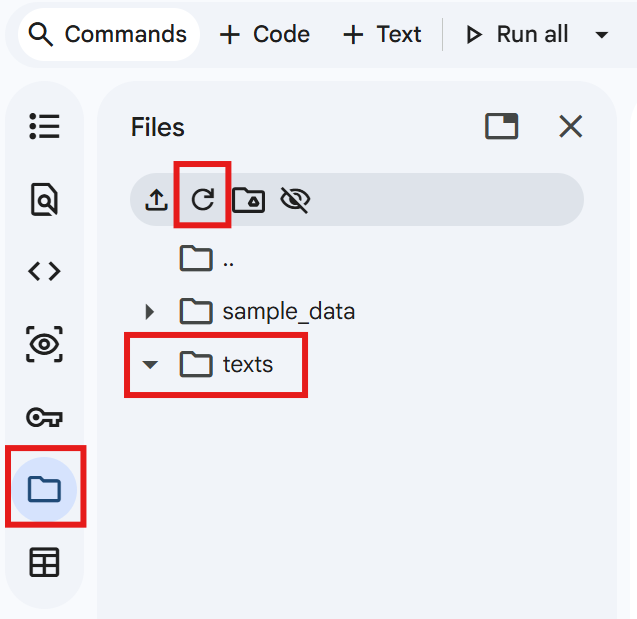

**Drag and drop your texts into that folder.**

NB: If you don't see a folder called "texts":
- If see a list of folders that starts with "bin", "boot", "content", etc.: click the **"content" folder**, which contains the "texts" folder.
- If you only see folders called ".." and "sample_data": try pressing the **refresh ⟳ button** in the Files drawer first; if the "texts" folder still does not appear, press the play button in the code cell above again. The "texts" folder should appear now.

## Step 3: Preprocessing

### Step 3.1: Chunking the text


In order to make comparing books of various length easier, we divide the books into equal-lenght chunks - the KITAB project uses chunks of 300 tokens.

The script in the code block below inserts "milestone" tags into the original text files that mark the end of each chunk, so that it becomes easier to trace a chunk to its position in the text.

Here is an example from OpenITI of a milestone marker (ms173) in a text - this tag means that after this point, the 174th 300-word chunk of text starts:

<blockquote>
لو انه أغنى بكيت كخندف % على الياس حتى ملها السر تندب
 إذا مؤنس لاحت خراطيم شمسه % بكت غدوة حتى ترى الشمس تغرب
 يعني بقوله مؤنس يوم الخميس لأن العرب كانت تسمي الأيام بغير أسمائها في
هذا الوقت فكانت تسمي الأحد الأول والاثنين أهون والثلاثاء جبار والاربعاء
دبار والخميس مؤنسا والجمعة عروبة والسبت شيار وكانوا يسمون أيام الشهر <mark style ="background-color:#0000FF">ms173</mark>
عشرة أسماء كل ثلاث ليال اسم فالثلاث التي أول الهلال الغرر ثم النفل ثم
التسع ثم العشر ثم البيض ثم الظلم ثم الخنس ثم الحنادس ثم المحاق والآخر
ليلة السرار إذا استسر الهلال وكانوا يسمون المحرم مؤتمرا وصفرا ناجرا
وربيعا الأول خوان وربيعا الآخر وبصان وجمادى الأول حنين وجمادى الآخرة ربى
ورجبا الأصم وشعبان العاذل ورمضان ناتقا وشوالا وعلا وذا القعدة ورنة وذا
الحجة بركا وكان آخرون من العرب يسمون الثلاث ليال من أول الشهر هلالا ثم
ثلاث قمر حين يقمر ثم ثلاث بهر حين يضيء ويبهر لونه وثلاث نقل وثلاث بيض
وثلاث درع وثلاث ظلم وثلاث حنادس وثلاث دآدي وليلتان محاق وليلة سرار
وولد لطانجة بن إلياس اد فتفرقت من ولد اد بن طانجة أربع
</blockquote>

**Run the code cell below by clicking the play button. It will ask you what script your texts is in before it proceeds**

NB: If you would like to customize the code (not necessary in most cases), here are some pointers:
- If the code is not visible, click "show code" first.
- The script is designed to split off a metadata header from the body of the text. By default, it uses the pattern that ends the metadata header of [OpenITI](https://openiti.org/projects/OpenITI%20Corpus.html) texts ("#META#Header#End") to do this; if your text contains a different pattern to separate the header from the body of the text, change the `META_SPLITTER` constant in the configuration block at the top of the script. The script also works if the text does not have any splitter - it will take the whole content of the text file as the body text.
- The default pattern for existing milestone tags is "\sms[A-Z]?\d+" (a space followed by the letters "ms", optionally an upper-case letter, and one or more digits). For a different pattern, change the constant value `MS_REMOVE_REGEX`.

In [ ]:
# @title Add milestones to your text files

#################
# CONFIGURATION #
#################

# ADAPT THE FOLLOWING CONSTANTS IF RELEVANT:
INPUT_FOLDER = "texts"                    # only change this if you put your texts in a different folder
MILESTONE_LENGTH = 300                    # 300 words works well for us but feel free to experiment with different sizes
META_SPLITTER = "#META#Header#End#"       # replace with the pattern that defines the start of your text.

# OTHER CONSTANTS - CHANGE ONLY IF YOU KNOW WHAT YOU'RE DOING
TOKEN_REGEXES = {
    "arabic": r"[\p{Arabic}\p{Diacritic}]+",    # any sequence of Arabic-script letters and/or diacritics
    "greek":  r"[\p{Greek}\p{Diacritic}]+",     # any sequence of Greek-script letters and/or diacritics
    "latin":  r"[\p{Latin}\p{Diacritic}]+",     # any sequence of Latin-script letters and/or diacritics
    "multiple": r"[\w\p{Diacritic}]+",          # any sequence of letters and/or diacritics
    "other":  r"[\w\p{Diacritic}]+"             # any sequence of letters and/or diacritics
}
LOG_FILE = "milestones.log"
FILE_PATTERN = r".*\.txt$"
MS_FIND_REGEX = r"ms[A-Z]?\d+"
MS_REMOVE_REGEX = r"\sms[A-Z]?\d+"
MILESTONE300_REGEX = r"\s*Milestone300"
# Set to True to process files even when the META_SPLITTER is missing
PROCESS_WITHOUT_SPLITTER = True
TAGS_NOT_TOKENS = [
    # structural tags like ### |EDITOR|, ### |PARATEXT|:
    r"[|$][A-Z]+[|$]",
    # semantic tags:
    r"@",
    r"\bY[A-Z]?\d+\b",
    # page number tags:
    r"(?:Folio|Page)(?:Beg|Beginning|End)?V",
    # milestone tags:
    r"\bms[A-Z]?\d+",
    # markdown image links and urls:
    r"!?\[[^\]]*\]\([^)]*\)",
    # numbers only should be counted as token,
    # but not number+non-letter character (e.g., 1., (1), ...):
    r"^\W*\d+\W+$"
]

#################

def ask_script():
    options_list = [key.capitalize() for key in TOKEN_REGEXES]
    options = ", ".join(options_list)
    print("In which script are your texts written?")
    print(f"Choose one of: {options}")
    script = input("and confirm by pressing Enter: ")
    if script and script.capitalize() in options_list:
        return script
    else:
        print(f"Unknown option: '{script}'. Try again...")
        return ask_script()

def define_token_regex(script):
    for key, tok_regex in TOKEN_REGEXES.items():
        if key.lower() in script.lower():
          return tok_regex

#################

# Milestoning script by Masoumeh Seydi

import os
import regex as re
import sys
import math
from collections import Counter
from itertools import groupby
from typing import Optional

def insert_milestones(
    filepath: str, length: int, token_regex: str, tags_regex: str, last_ms: int, log_file
) -> Optional[int]:
    """
    Read `filepath`, strip old milestone tags, and insert new ones every `length`
    Arabic tokens, continuing count from `last_ms`. Returns final ms count,
    or None on error.
    """
    # filename = os.path.basename(filepath)
    # name_base = re.split(r"-[a-z]{3}\d", filename)[0]

    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()

    # Split header/body, optionally skipping the missing‐splitter error
    if META_SPLITTER in content:
        header, body = map(str.rstrip, content.split(META_SPLITTER, 1))
        log_file.write(f"[DONE] Splitter in {filepath}, milestoned!\n")
    elif not PROCESS_WITHOUT_SPLITTER:
        log_file.write(f"[ERROR] Missing splitter in {filepath}, no changes made!\n")
        return None
    else:
        # No splitter but we're configured to proceed:
        header = ""
        body = content#.rstrip()
        log_file.write(f"[WARN] Missing splitter in {filepath}, milestoned!\n")

    # Remove old milestone tags, including the old pattern (Milestone300)
    body = re.sub(MS_REMOVE_REGEX, "", body)
    body = re.sub(MILESTONE300_REGEX, "", body)

    # Count all tokens in the text to check how many digits the milestone tag should contain:
    total_toks = len(re.findall(token_regex, body))
    pad_len = len(str(math.floor(total_toks / length)))

    # go through all the tokens in the text and insert the milestone tag in the right place:
    count, ms_count = 0, last_ms
    new_parts = []

    tokens = re.split("("+token_regex+")", body)  # this includes both tokens and non-tokens!
    for i, tok in enumerate(tokens):
        new_parts.append(tok)
        if re.search(token_regex, tok) and not re.search(tags_regex, tok):
            count += 1

        # Time to insert a milestone?
        if count >= length or i == len(tokens) - 1:
            ms_count += 1
            tag = f" ms{ms_count:0{pad_len}d}"
            new_parts.append(tag)
            count = 0

    new_body = "".join(new_parts)

    # Verify no corruption
    if re.sub(MS_REMOVE_REGEX, "", new_body) != body:
        log_file.write(f"[ERROR] Content mismatch in {filepath}\n")
        return None

    # Check for duplicates
    ids = re.findall(MS_FIND_REGEX, new_body)
    dupes = {k: v for k, v in Counter(ids).items() if v > 1}
    if dupes:
        log_file.write(f"[ERROR] Duplicate IDs in {filepath}: {dupes}\n")
        return None

    # Write out
    if META_SPLITTER in content:
      final = header + "\n\n" + META_SPLITTER + "\n\n" + new_body
    else:
      final = new_body
    with open(filepath, "w", encoding="utf-8") as f:
        f.write(final)

    return ms_count


def process_files(input_folder: str, ms_length: int, token_regex: str, tags_regex: str) -> None:
    """
    Walk `input_folder`, find matching text files, and insert milestones.
    """
    # check if the input folder exists and contains text files:
    if not os.path.isdir(input_folder):
        print(f"Invalid path: {input_folder}")
        return  # sys.exit(1) inserts an ugly exception message in the output

    print("Inserting milestones...")

    total_ms_count = 0
    all_book_files = []
    all_visible_files = []
    with open(LOG_FILE, "w", encoding="utf-8") as log_file:
        for root, _, files in os.walk(input_folder):
            # Filter book files
            book_files = [
                os.path.join(root, f) for f in files if re.match(FILE_PATTERN, f)
            ]
            visible_files = [
                os.path.join(root, f) for f in files if (re.match("^[^.]", f) and os.path.isfile(os.path.join(root, f)))
            ]
            for fp in book_files:
                ms_count = insert_milestones(fp, ms_length, token_regex, tags_regex, 0, log_file)
                total_ms_count += ms_count
            all_book_files += book_files
            all_visible_files += visible_files

    # handle empty input folder or wrong file pattern:
    all_non_text_files = [f for f in all_visible_files if f not in all_book_files]
    if len(all_book_files) == 0:
        print(f"No files that follow the pattern for text files ('{FILE_PATTERN}') found in the input folder '{input_folder}'.")
        return
    elif len(all_non_text_files) > 0:
        print(f"These files in the input folder do not follow the pattern for text files ('{FILE_PATTERN}').")
        for f in all_non_text_files:
            print("*", f)
        print("Fix the filename(s) or remove the file(s) from the folder")
        print("and rerun the code cell before continuing.")
        return
    else:
        return total_ms_count, len(all_book_files)

SCRIPT = ask_script()
token_regex = define_token_regex(SCRIPT)
tags_regex = re.compile("|".join(TAGS_NOT_TOKENS))

r = process_files(INPUT_FOLDER, MILESTONE_LENGTH, token_regex, tags_regex)

if r:
    total_ms_count, n_book_files = r

    print(f"Done! Inserted {total_ms_count} milestones in {n_book_files} text files.")
    print(f"You can double-click one of your text files in the '{INPUT_FOLDER}' folder in the left-hand side bar")
    print("to see the milestones in place. (search the text for 'ms')")


### Step 3.2: Generating input files for passim

Run the script in the code block below, which generates input files for passim from the chunked input texts.

The passim input files are in [JSON Lines format](https://jsonlines.org//) : they contain containing one JSON record per line. Each of these records represents a single text chunk and looks like this:

```
{"id": "ms1", "series": "myFirstTextFile", "text": "This is text."}
```

("id" being the milestone number, and "series" the text filename)

In addition to the above fields, other metadata included in the record for each document will be passed through into the output.

The passim input is **normalized** to facilitate comparison (e.g., Latin-script texts are lower-cased, punctuation is removed). If you know what you're doing, you can adapt the normalization function for your texts' script at the top of the code block.

**Run the code cell by clicking the button. If the notebook forgot the script of your texts, it will ask you again.**

In [ ]:
# @title Create json files for passim input

#################
# CONFIGURATION #
#################

MAIN_FOLDER = "texts"
TARGET_FOLDER = "passim_inputs"
LOG_FILE = "passim_inputs_log.csv"
META_SPLITTER = "#META#Header#End#"

############################################
# TEXT CLEANING / NORMALIZATION FUNCTIONS: #
############################################

import unicodedata
import regex as re

def general_cleaner(text):
    # lower-case the text:
    text = text.lower()
    # remove hyphens at the end of a line:
    text = re.sub(r"[ \t]*- [ \t]*\n+ [ \t]*", "", text)
    # break apart complex unicode characters:
    text = unicodedata.normalize("NFKD", text)
    # remove diacritics:
    text = re.sub(r"[\p{Diacritic}]+", "", text)
    return text

def greek_cleaner(text):
    # lower-case, remove hyphens and diacritics:
    text = general_cleaner(text)
    # replace any sequence of characters that are not a Greek letter or a space by a space
    text = re.sub(r"[^\p{Greek}]+", " ", text)
    return text.strip()

def latin_cleaner(text):
    # lower-case, remove hyphens and diacritics:
    text = general_cleaner(text)
    # replace any sequence of characters that are not a Latin letter or a space by a space
    text = re.sub(r"[^\p{Latin}]+", " ", text)
    return text.strip()

def arabic_cleaner(text):
    # remove vowels and other noise:
    text = ara.denoise(text)
    # normalize Arabic characters and remove digits and non-Arabic characters (except spaces):
    text = funcs.text_cleaner(text)
    return text.strip()

def other_cleaner(text):
    # lower-case, remove hyphens and diacritics:
    text = general_cleaner(text)
    # replace any sequence of digits and non-letter characters by a single space:
    text = re.sub(r"[\W\d]+", " ", text)
    return text.strip()

TEXT_CLEANERS = {
    "arabic": arabic_cleaner,
    "greek": greek_cleaner,
    "latin": latin_cleaner,
    "multiple": other_cleaner,
    "other": other_cleaner
}

def ask_script():
    options_list = [key.capitalize() for key in TEXT_CLEANERS]
    options = ", ".join(options_list)
    script = input(f"In which script are your texts written? (Choose one of: {options}) ")
    if script and script.capitalize() in options_list:
        return script.lower()
    else:
        print(f"Unknown option: '{script}'. Try again...")
        return ask_script()

def define_cleaning_function(script):
    cleaning_func = None
    for key, cleaning_func in TEXT_CLEANERS.items():
        if key.lower() in script.lower():
            if key.lower() == "arabic":
                # Check if the necessary libraries are available and import/load them otherwise:
                try:
                    ara.denoise
                except:
                   !pip install openiti
                   from openiti.helper import ara, funcs
            return cleaning_func
    if not cleaning_func:
        print(f"No cleaning function found for your script {script}. Will use a general-purpose cleaning function.")
        return other_cleaner


#################

# passim inputs script by Masoumeh Seydi

import os
import sys
import csv
from itertools import groupby
import pandas as pd


def mechanical_chunking(filename, text, output_dir, milestone_pattern, chunk_size, text_cleaner):
    """
    Split `text` on each occurrence of `milestone_pattern`, clean it,
    and write JSON-like chunks of size `chunk_size` to files in `output_dir`.
    Returns the number of chunks that were written, 0 if the last expected chunk already exists.
    """
    # Derive a simple book ID and prepare output path prefix
    book_id = re.sub(r"(\.txt)$", "", filename)
    prefix = os.path.join(output_dir, book_id)

    # If the final chunk file already exists, skip
    final_path = f"{prefix}-{chunk_size:05d}"
    if os.path.exists(final_path):
        return 0

    # Split on the milestone markers, keeping them in the list
    parts = re.split(fr"({milestone_pattern})", text)
    template = '{{"id":"{id}", "series":"{series}", "text":"{text}", "seq":{seq}}}'
    records = []
    counter = 0
    i = 0

    while i < len(parts) - 2:
        counter += 1
        marker = parts[i + 1]
        # remove vowels
        clean_text = text_cleaner(parts[i])

        seq = int(re.sub(r"\D", "", marker))
        rec = template.format(
            id=f"{book_id}.{marker}",
            series=book_id,
            text=clean_text,
            seq=seq
        )
        records.append(rec)

        # Write out in batches of chunk_size
        if counter % chunk_size == 0:
            path = f"{prefix}-{counter:05d}.json"
            with open(path, "w", encoding="utf8") as fw:
                fw.write("\n".join(records))
            records = []

        i += 2

    # Write any remaining records
    # Round up to the next multiple of chunk_size
    final_counter = ((counter + chunk_size - 1) // chunk_size) * chunk_size
    path = f"{prefix}-{final_counter:05d}.json"
    with open(path, "w", encoding="utf8") as fw:
        fw.write("\n".join(records))

    #return 1
    return counter

def main(main_folder, target_folder, text_cleaner):
  # Create or empty the passim inputs folder:
  try:
    os.makedirs(target_folder, exist_ok=False)
    print("Passim inputs folder created.")
  except:
    print("Emptying the passim inputs folder.")
    import shutil
    shutil.rmtree(target_folder)
    os.makedirs(target_folder)

  # Validate paths
  if not os.path.exists(main_folder):
    print(main_folder)
    print(f"Invalid path: {main_folder}", file=sys.stderr)
    sys.exit(1)

  print("\nGenerating passim input json files...\n")

  # Constants
  milestone = r"ms[A-Z]?\d+"
  chunk_size = 1000
  written = []
  total = 0

  for root, _, files in os.walk(main_folder):
      # Match files like filename.txt
      pattern = r".+(\.txt)$"
      candidates = [f for f in files if re.match(pattern, f)]
      if not candidates:
          continue

      # Process each file
      for filename in candidates:
          path = os.path.join(root, filename)
          with open(path, encoding="utf8") as file:
              content = file.read()
              if META_SPLITTER in content:
                body = content.split(META_SPLITTER)[1]
              else:
                body = content

          n_chunks = mechanical_chunking(
              filename, body, target_folder, milestone, chunk_size, text_cleaner
          )
          print(n_chunks, "chunks in", filename)
          total += n_chunks
          book_id = re.sub(r"(\.txt)$", "", filename)
          written.append((book_id, n_chunks))

          if total % 100 == 0:
              print(f"\nProcessed: {total}\n" + "=" * 20 + "\n")

  # Write a log of what was written
  with open(LOG_FILE, "w", newline="", encoding="utf8") as log_f:
      writer = csv.writer(log_f)
      writer.writerow(["book_id", "number_of_documents"])
      writer.writerows(written)

  print("\nDone! Your input files for passim are now in the", target_folder, "folder")
  print("The passim input contains", total, "documents.")
  print("You can inspect the files by double-clicking one of the files in the passim_inputs folder")

# ask the user for the script again if the notebook was inactive for too long:
try:
    SCRIPT
except:
    SCRIPT = ask_script()
text_cleaner = define_cleaning_function(SCRIPT)
main(MAIN_FOLDER, TARGET_FOLDER, text_cleaner)


## Step 4: Set the passim parameters and run passim


Passim has many parameters that can be tweaked to adapt it to your corpus and the type of text reuse you want to retrieve. Ideally, you want to find parameters that return text reuse with
* high recall: it finds all or most instances of text reuse you are interested in;
* high precision: the results don't include many "false positives": irrelevant instances (formulaic or common language)

(For full documentation of passim and how to run it, see https://github.com/dasmiq/passim). The following parameters make sense for the KITAB corpus:

```
-n 25 --maxDF 100 --min-match 5 --min-align 20 --pairwise --filterpairs 'gid < gid2'
```

* `-n 25`: passim will use n-grams consisting of 25 consecutive characters (ca. 4-5 words) to find possibly relevant pairs. Use smaller n-grams if you want to retrieve shorter passages (but this may also increase the number of false positives)
* `--maxDF 100` : any n-gram that is present in more than 100 text chunks will be considered trivial (that is, so common that it is not indicative of text reuse). Use a lower number if you have a small corpus, and increase the number if you notice a lot of formulaic text in your results.
* `--min-match 5` : pairs with less than 5 shared non-trivial n-grams will not be considered.
* `--min-align 30` : alignments need to be at least 30 characters long
* `-- gap 200` : alignments less than 200 characters apart will be merged together into a single alignment
* `--pairwise` invokes passim to output pairwise alignments between all matching passages (in addition to the cluster data). Don't change this parameter if you want to use the text reuse data in the KITAB visualization app.
* `--filterpairs 'gid < gid2'` tells passim to compare all chunks from the same pair of books in the same direction (book 1 to book 2, not book 2 to book 1); it also prevents comparing chunks from the same book to each other.

You can tweak the parameters in the configuration of the code block below. It usually takes a number of experiments to get the parameters right (that is, to retrieve all relevant text reuse and not retrieve irrelevant common language).

**Once you have set the parameters, run the code cell.** This may take up to 30 minutes, depending on the parameters, the busyness of Google's servers, and the size of the corpus.

NB: running the code cell will remove any old outputs.



In [ ]:
# @title Run passim

################
# CONFIGURATION #
################

parameters = {
    "-n": 8,
    "--maxDF": 15,
    "--min-match": 3,
    "--min-align": 15,
    "--filterpairs": "'gid < gid2'",  # Note the double set of quotation marks! A single set will not work!
    "--gap": 30,
    "--pairwise": True                # don't change this if you want to view output in a spreadsheet or KITAB visualization app
}

# do not change these unless you know what you're doing:
input_dir = "passim_inputs"
output_dir = "passim_output_json"
spark_driver_mem = "6G"
spark_executor_mem = "6G"
log_level = "WARN"  # Options, from least to most output: "ERROR", "WARN", "INFO", "DEBUG"
log_file = "passim_output.log"

##############
# RUN PASSIM #
##############

# FROM DAVID'S NOTEBOOK: https://colab.research.google.com/github/dasmiq/passim/blob/main/docs/passim_quickstart.ipynb#scrollTo=hZBefy-B1S01
# This takes input files in passim_inputs dir (created by the above steps)

import os
import shutil
# install passim if it was not already installed:
try:
    import passim
    print("Passim was already installed")
except:
    print("Installing passim...")
    !pip install git+https://github.com/dasmiq/passim.git

# Delete old output:
if os.path.exists(output_dir):
  print("Removing old output...")
  shutil.rmtree(output_dir)
if os.path.exists(log_file):
  os.remove(log_file)

k_v_arguments = " ".join([f"{key} {value}" for key, value in parameters.items() if type(value) != bool])
k_arguments = " ".join([f"{key}" for key, value in parameters.items() if type(value) == bool and value == True])
cmd = f"""
SPARK_SUBMIT_ARGS="--driver-memory {spark_driver_mem} --executor-memory {spark_executor_mem}" \
passim {k_arguments} {k_v_arguments} --log-level {log_level} {input_dir} {output_dir} >& {log_file}
"""

print("\nRunning passim with this command:")
print(cmd)
print("NB: passim logs will be stored in", log_file)
!{cmd}

print(f"Done. The output files are in the {output_dir} folder")

Once the script has finished, passim's output files will be located in the folder `passim_output_json`. Press the refresh ⟳ button in the file drawer if you can't see it.

## Step 5: Post-processing

Passim outputs data in json format; in order to inspect the results in a spreadsheet, or to visualize them in the [KITAB visualization app](https://kitab-project.org/explore/#/visualise), we're going to convert these outputs into [comma-separated values file (CSV)](https://en.wikipedia.org/wiki/Comma-separated_values) and [tab-separated values file (TSV)](https://en.wikipedia.org/wiki/Tab-separated_values) files.

The code block below will create the following folders and files:

- `passim_output_csv/pairwise`: this folder contains a tsv file for each pair of your text files in which passim found chunks that contained text reuse.
- `passim_output_csv/one_to_all`: creates for every text file in your corpus (for which any text reuse was found), two csv files:
  - `<filename>_all.csv`: details all text reuse instances detected with this text file in all other texts in the corpus.
  - `<filename>_stats.csv`: contains summary statistics about how many text reuse instances to the target text file passim found in each other text in the corpus.

See below for a more detailed description of these files.

These CSV files can be loaded into the KITAB apps or inspected in a spreadsheet program (see below).

**Run the code block below to generate these folders and files.**

When the script is done, a zip file will be downloaded to your computer.

In [ ]:
# @title Convert the passim outputs into csv/tsv files

#################
# CONFIGURATION #
#################

INPUT_PATH = "passim_output_json/align.json"
PAIRWISE_PATH = "passim_output_csv/pairwise"
ONE_TO_ALL_PATH = "passim_output_csv/one_to_all"
STATS_PATH = None # put the stats files in the same folder as the detailed data files
# optionally, provide a corpus version, which will be used in the file names:
corpus_version = ""
# optionally, provide for each text file name a book title:
meta = {"example.txt": {"book": "Title of the Book"}}

#################

"""
This script augments Passim outputs (JSON or Parquet) with:
  - ch_match: character matches excluding whitespace
  - align_len: length of the aligned string
  - matches_percentage: (matches / align_len) * 100
  - w_match: word matches at identical positions

Outputs are written as partitioned CSVs by series/series2,
and post-processed to remove hidden files and rename parts.
"""

import time
import json
from collections import defaultdict
import shutil
from google.colab import files
from datetime import datetime
import csv
import os
import regex as re
from pathlib import Path
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql.types import IntegerType, FloatType
import pyspark.sql.functions as F

def word_count(s1: str, s2: str) -> int:
    """Count matching words between two aligned strings at identical positions."""
    cnt = 0
    i, n = 0, len(s1)
    while i < n:
        start = i
        while i < n and s1[i] != " ":
            i += 1
        if s1[start:i] == s2[start:i]:
            cnt += 1
        i += 1  # skip the space
    return cnt


def ch_count(s1: str, s2: str) -> int:
    """Count matching non-whitespace characters at identical positions."""
    return sum(1 for a, b in zip(s1, s2) if a == b and a != " ")


def match_percentage(matches: int, length: int) -> float:
    """Compute match percentage; return 0.0 if length is zero."""
    return (matches / length) * 100 if length > 0 else 0.0


def create_pairwise_csvs(input_path: str, output_path: str) -> None:
    spark = SparkSession.builder.appName("Stats").getOrCreate()

    # Register UDFs
    word_match_udf = F.udf(word_count, IntegerType())
    ch_match_udf = F.udf(ch_count, IntegerType())
    align_len_udf = F.udf(lambda s: len(s), IntegerType())
    percent_udf = F.udf(match_percentage, FloatType())

    # Determine format from extension
    fmt = Path(input_path).suffix.lower()
    if fmt == ".json":
        src_format = "json"
    elif fmt == ".parquet":
        src_format = "parquet"
    else:
        raise ValueError(f"Unsupported input format: {fmt}")

    # Load, dedupe, and drop nulls
    df = (
        spark.read
             .format(src_format)
             .option("encoding", "UTF-8")
             .load(input_path)
             .distinct()
             .na.drop()
    )
    # new_col_names = {'id':'id1', 'first': 'first1', 'uid':'uid1', 'bw':'bw1',
    #                 'ew': 'ew1', 'begin':'b1', 'begin2':'b2', 'end':'e1',
    #                 'end2': 'e2', 'len': 'len1',
    #                 'tok': 'tok1', 'seq': 'seq1', 'gid': 'gid1'
    #                 , 'series': 'series1', 'mathces_percentage': 'matches_percent'}
    #                 #  , 'series2': 'series_b2'}

    # for old_name, new_name in new_col_names.items():
    #     df = df.withColumnRenamed(old_name, new_name)

    # Compute new columns
    df2 = (
        df
        .withColumn("ch_match", ch_match_udf("s1", "s2"))
        .withColumn("align_len", align_len_udf("s1"))
        .withColumn(
            "matches_percentage",
            F.when(F.col("align_len") == 0, F.lit(0.0))
             .otherwise(percent_udf(F.col("matches"), F.col("align_len")))
        )
        .withColumn("w_match", word_match_udf("s1", "s2"))
        .withColumn('series_b1', F.col('series')) \
        .withColumn('series_b2', F.col('series2')) \

    )

    # Write partitioned CSV output
    df2.repartition("series", "series2") \
       .sortWithinPartitions("id", "id2") \
       .write \
       .partitionBy("series", "series2") \
       .format("csv") \
       .option("header", "true") \
       .option("delimiter", "\t") \
       .mode("overwrite") \
       .save(output_path)

    spark.stop()

    # Post-process: remove hidden files, rename part files, and clean directories
    for root, _, files in os.walk(output_path, topdown=False):
        root_path = Path(root)

        # Inside a series2 partition
        if any(p.startswith("series2=") for p in root_path.parts):
            # Delete hidden files (e.g. ._SUCCESS)
            for f in files:
                if f.startswith("."):
                    (root_path / f).unlink()

            # Rename the first part file to SERIES_SERIES2.csv
            parts = [f for f in files if f.startswith("part")]
            if parts:
                series = next((p.split("=", 1)[1] for p in root_path.parts if p.startswith("series=")), "")
                series2 = next((p.split("=", 1)[1] for p in root_path.parts if p.startswith("series2=")), "")
                new_name = f"{series}_{series2}.csv"
                parent = root_path.parent
                os.rename(root_path / parts[0], parent / new_name)

            # Remove the now-empty series2 directory
            root_path.rmdir()

        # Rename the series directory to drop the prefix
        elif any(p.startswith("series=") for p in root_path.parts):
            new_dir = re.sub(r"series=", "", str(root_path))
            os.rename(root, new_dir)


def extract_milestone_data_from_file(file, ms_data, main, comp,
                                     main_col, comp_col):
    """"Extract start and end of each reused milestone

    Args:
        file (file object)
        ms_data (defaultdict): contains for each milestone in the `main` text
            a dictionary of other texts in which this milestone is reused:
            ms_data[main_ms][comp][comp_ms][comp_bw] = {"comp_bw":, "comp_ew":, "comp_s":,
                                                        "main_bw":, "main_ew":, "main_s":
                                                        }
        main (str): id of the main book (derived from the srt file name).
        comp (str): id of the compared book (derived from the srt file name).
        main_col (str): is the main book bk1 or bk2 in the srt file? "1" or "2".
        comp_col (str): is the compared book bk1 or bk2 in the srt file? "1" or "2".
    """
    # deal with different column names in different passim versions:
    reader = csv.DictReader(file, delimiter="\t")
    if "begin" in reader.fieldnames:
        begin = "begin"
        end = "end"
        pct = "matches_percentage"
        main_s = "s"+main_col
        comp_s = "s"+comp_col
        if main_col == "1":
            main_col = ""
        elif comp_col == "1":
            comp_col = ""
    else:
        begin = "b"
        end = "e"
        pct = "matches_percent"

    # rewind to the beginning of the file and get the data from each row:
    file.seek(0)
    for row in csv.DictReader(file, delimiter="\t"):
        try:
            main_ms = int(re.findall(r"\d+$", row["id"+main_col])[0])
        except Exception as e:
          print("ERROR:", e, row)
          input("CONTINUE?")
        main_b = int(row[begin+main_col])
        main_e = int(row[end+main_col])
        comp_ms = int(re.findall(r"\d+$", row["id"+comp_col])[0])
        comp_b = int(row[begin+comp_col])
        comp_e = int(row[end+comp_col])
        ch_match = int(row["ch_match"])
        matches_percent = int(float(row[pct]))
        ms_data[main_ms].append({
            "b1": main_b,
            "e1": main_e,
            "id2": comp.split("-")[0],
            "ms2": comp_ms,
            "b2": comp_b,
            "e2": comp_e,
            "ch_match": ch_match,
            "matches_percent": matches_percent,
            "s1": row[main_s],
            "s2": row[comp_s]
        })



def compute_stats(ms_data, meta={}):
    """Compute reuse statistics for each book

    Args:
        ms_data (dict): reuse data, organized by milestone number
            of the main book
        meta (dict): additional title metadata about each book
            {id: {"book": title}, }

    Returns:
        dict
    """
    stats = dict()
    for ms1, reuse in ms_data.items():
        for d in reuse:
            id2 = d["id2"]
            if "-" in id2:
                id2 = id2.split("-")[0]
            if not id2 in stats:
                try:
                    book = meta[id2]["book"]
                except:
                    book = id2
                stats[id2] = {"alignments": 0, "ch_match": 0, "book": book}
            stats[id2]["alignments"] += 1
            stats[id2]["ch_match"] += d["ch_match"]
    return stats


def extract_milestone_data_from_folder(folder, outfolder, stats_folder,
                                       corpus_version,
                                       single_json=True, csv_output=True,
                                       indent=None, verbose=True):
    """Extract for every milestone in the main text all corresponding
    milestones from all csv files in `folder` and save them as json file(s)

    Args:
        folder (str): path to the folder containing the srt files
        outfolder (str): path to the output folder
        stats_folder (str): path to the folder where stats will be stored
        corpus_version (str): number of the OpenITI corpus version
            related to this passim run
            (<year>.<nth_run_this_year>.<nth_run_in_total>, e.g., 2021.2.5)
        single_json (bool): if True, all milestone data will be in
            a single json file; if False, one json file will be
            created for each milestone
        indent (int): number of spaces by which the json output
            will be indented (0 = no spaces, but each key-value pair
            on a new line). Defaults to None (no indentation nor new lines)
        csv_output (bool): if True, csv output will be created rather than json
        verbose (bool): if True, srt file names will be printed out
            as they are being processed
    """
    if not stats_folder:
        stats_folder = outfolder
    # define which book is the main book by checking all csv filenames:
    count = defaultdict(int)
    for fn in os.listdir(folder):
        if not fn.endswith(("json", "_all.csv", "_stats.csv")):
            bk1, bk2 = ".".join(fn.split(".")[:-1]).split("_")
            count[bk1] += 1
            count[bk2] += 1
            if count[bk1] > 3 or count[bk2] > 3:
                break

    main = sorted(count.items(), key=lambda item: item[1], reverse=True)[0][0]
    # NB: main is the version ID + extension!
    main = main.split("-")[0]

    ms_data = defaultdict(list)
    for fn in os.listdir(folder):
        if not fn.endswith(("json", "_all.csv", "_stats.csv")):
            if verbose:
                print(fn)
            fp = os.path.join(folder, fn)
            bk1, bk2 = ".".join(fn.split(".")[:-1]).split("_")
            bk1 = bk1.split("-")[0]
            bk2 = bk2.split("-")[0]
            if bk1 == main:
                comp = bk2
                main_col = "1"
                comp_col = "2"
            else:
                comp = bk1
                main_col = "2"
                comp_col = "1"

            if not fp.endswith("gz"):
                with open(fp, mode="r", encoding="utf-8") as file:
                    extract_milestone_data_from_file(file, ms_data, main, comp,
                                                     main_col, comp_col)
            else:
                with gzip.open(fp, mode="rt", encoding="utf-8") as file:
                    extract_milestone_data_from_file(file, ms_data, main, comp,
                                                     main_col, comp_col)

    # compute statistics: how many alignments, how many characters matched
    # for every book2:
    stats = compute_stats(ms_data, meta)


    # Create output:
    if csv_output:
        if corpus_version:
            outfp = os.path.join(outfolder, "{}_{}_all.csv".format(corpus_version, main))
        else:
            outfp = os.path.join(outfolder, "{}_all.csv".format(main))
        rows = ["ms1,b1,e1,id2,ms2,b2,e2,ch_match,matches_percent,s1,s2",]
        for ms1 in sorted(ms_data.keys()):
            for d in ms_data[ms1]:
                row = [ms1, d["b1"], d["e1"], d["id2"], d["ms2"],
                       d["b2"], d["e2"], d["ch_match"], d["matches_percent"], d["s1"], d["s2"]]
                rows.append(",".join([str(x) for x in row]))
##            for id2 in ms_data[ms1]:
##                for ms2 in ms_data[ms1][id2]:
##                    for b2, d in ms_data[ms1][id2][ms2].items():
##                        row = [ms1, d["b1"], d["e1"], id2, ms2, b2, d["e2"], d["ch_match"]]
##                        rows.append(",".join([str(x) for x in row]))
        with open(outfp, mode="w", encoding="utf-8") as file:
            file.write("\n".join(rows))

        if corpus_version:
            stats_fp = os.path.join(stats_folder, "{}_{}_stats.csv".format(corpus_version, main))
        else:
            stats_fp = os.path.join(stats_folder, "{}_stats.csv".format(main))
        with open(stats_fp, mode="w", encoding="utf-8") as file:
            csv_stats = [[id2, d["book"], str(d["alignments"]), str(d["ch_match"])] for id2, d in stats.items()]
            csv_stats = [",".join(row) for row in sorted(csv_stats)]
            file.write("id,book,alignments,ch_match\n" + "\n".join(csv_stats))
    else:
        if single_json:
            if corpus_version:
                outfp = os.path.join(outfolder, "{}_{}_all.json".format(corpus_version, main))
            else:
                outfp = os.path.join(outfolder, "{}_all.json".format(main))
            with open(outfp, mode="w", encoding="utf-8") as file:
                json.dump(ms_data, file, sort_keys=True, indent=indent)
        else:
            for ms in ms_data:
                if corpus_version:
                    outfp = os.path.join(outfolder, "{}_{}_ms{}.json".format(corpus_version, main, ms))
                else:
                    outfp = os.path.join(outfolder, "{}_ms{}.json".format(main, ms))
                with open(outfp, mode="w", encoding="utf-8") as file:
                    json.dump({"data": ms_data[ms]}, file,
                              sort_keys=True, indent=indent)
        if corpus_version:
            stats_fp = os.path.join(stats_folder, "{}_{}_stats.json".format(corpus_version, main))
        else:
            stats_fp = os.path.join(stats_folder, "{}_stats.json".format(main))
        with open(stats_fp, mode="w", encoding="utf-8") as file:
            stats = [{"id": id2, "alignments": d["alignments"],
                      "ch_match": d["ch_match"], "matches_percent": d["matches_percent"]}\
                     for id2,d in stats.items()]
            json.dump({"stats": stats}, file, sort_keys=True, indent=indent)

    return ms_data

def create_one_to_all_csvs(PAIRWISE_PATH, ONE_TO_ALL_PATH, STATS_PATH,
                                       corpus_version):
    for i, id_ in enumerate(os.listdir(PAIRWISE_PATH)):
        srt_folder = os.path.join(PAIRWISE_PATH, id_)
        if not os.path.isdir(srt_folder):
            continue
        print("-", id_)
        extract_milestone_data_from_folder(srt_folder, ONE_TO_ALL_PATH, STATS_PATH,
                                          corpus_version,
                                          single_json=True, csv_output=True,
                                          verbose=False, indent=0)

def download_zip(zip_fp):
    # create a README file with the configuration used:
    timestamp = datetime.now().strftime("%d %B %Y, %H:%M")
    readme = f"# Passim data downloaded on {timestamp}."
    try:
        parameters_used = "\n".join([f"{key} {value}" for key, value in parameters.items()])
        readme += f"""

## Passim parameters used:

```
{parameters_used}
```
"""
    except:
        pass

    if os.path.exists("texts"):
        readme += f"""

## Texts compared:

* {"\n* ".join(os.listdir("texts"))}
"""

    with open("passim_output_csv/README.md", mode="w", encoding="utf-8") as file:
        file.write(readme)


    shutil.make_archive(zip_fp.replace(".zip", ""), "zip", "passim_output_csv")
    files.download(zip_fp)



# check the input and output paths:
if not os.path.exists(INPUT_PATH):
    print(f"Invalid path: {INPUT_PATH}", file=sys.stderr)
    sys.exit(1)

print("Creating / emptying the CSV output folders...")
for folder in [PAIRWISE_PATH, ONE_TO_ALL_PATH, STATS_PATH]:
    if folder:
        if os.path.exists(folder):
            shutil.rmtree(folder)
        os.makedirs(folder)

print("Generating the pairwise TSV files...")
create_pairwise_csvs(INPUT_PATH, PAIRWISE_PATH)
print(f"Pairwise files done! The pairwise TSV files can be found in the {PAIRWISE_PATH} folder")
print("--------------")

print("Generating the one-to-all TSV files...")
create_one_to_all_csvs(PAIRWISE_PATH, ONE_TO_ALL_PATH, STATS_PATH, corpus_version)
print(f"One-to-many files done! The one-to-all TSV files can be found in the {ONE_TO_ALL_PATH} folder")

print("--------------")
print("Creating and downloading zip file...")
zip_timestamp = datetime.now().strftime("%Y-%m-%d_%Hh%M")
zip_fp = f"passim_output_{zip_timestamp}.zip"
download_zip(zip_fp)
print(f"Success! The zip file ({zip_fp}) should be in your computer's Downloads folder!")

### Column description: pairwise files

When the script is done, the pairwise tsv files will be in the `passim_output_csv/pairwise` folder.

The columns generated by passim include:

* `s1`: aligned sequence in book 1
* `s2`: aligned sequence in book 2
* `matches`: number of matches in aligned sequences
* `begin`: begin point of alignment (in characters) in milestone 1
* `begin2`: begin point of alignment (in characters) in milestone 2
* `end`: end point of alignment (in characters) in milestone 1
* `end2`: end point of alignment (in characters) in milestone 2
* `series`: series identifier (input text filename) for book 1
* `series2`: series identifier (input text filename) for book 2
* `seq`: chunk (milestone) id in book 1.
* `seq2`: chunk (milestone) id in book 2.
* `id`: full id of text chunk from book 1 (combines fields `series`and `seq`)
* `id2`: full id of text book 2 (combines fields `series2`and `seq2`)
* `gid`: hash of `series` field
* `gid2`: hash of `series2` field
* `uid`: hash of `id` field
* `uid2`: hash of `id2` field

Following columns are added by the post-processing script:

* `w_match`: count of complete words matched in the alignment (excluding whitespace)
* `ch_match`: count of characters matched in the alignment
* `align_len`: length of the alignment
* `matches_percentage`: percentage of characters in the alignment that match in `s1` and `s2`


### Column description: one-to-all files

These files can be found in this folder: `passim_output_csv/one_to_all`.

For each text file in the corpus for which passim found any text reuse, this folder contains two tsv files:

1. `<text_id>_all.csv`:

This file contains the data of all alignments with this text in the entire corpus.

The columns include:

* `ms1`: the milestone in the target text
* `b1`: begin point of alignment in characters in the target text
* `e1`: end point of alignment in characters in the target text
* `id2`: text ID of the other text
* `ms2`: the milestone in the other text
* `b2`: begin point of alignment in characters in the other text
* `e2`: end point of alignment in characters in the other text
* `ch_match`: count of characters that match in the same position in the alignment
* `matches_percent`: percentage of characters that match in the same position in the alignment

2. `<text_id>_stats.csv`:

This file contains statistics and metadata for every book in the corpus for which passim detected alignments with the target text:

The columns include:
* `id`: text ID of the other text
* `book`: book URI of the other text (will be the same as the file name of the text, unless you provided additional metadata)
* `alignments`: number of alignments with the target text
* `ch_match`: total count of characters matched in alignments with the target text

## Step 6: Visualisation and analysis

After the script has run, you will find the outputs in the 'passim_output_csv/pairwise' and 'passim_output_csv/one_to_all' folders. A zip file containing all these files and folders should be in your computer's Downloads folder.

You can download an output file and read it directly in a spreadsheet program like **MS Excel or Google Sheets** or upload it into one of the KITAB apps.

### 6.1 Read the files in a spreadsheet program

You can download and read an output tsv file in **excel or google sheets**.

NB: although the pairwise output files have the extension ".csv", they use tabs as separators. To open them in any spreadsheet software, make sure to use `Tab` as the separator, not comma!

As the output is a tsv and may contain non-Latin script, to open it in MS Excel you will need to import it through the data tab. To do so follow these steps:
1. Open Excel and create a new spreadsheet
1. Go to the 'Data' tab
1. Click 'Get Data' --> 'From File' --> 'From Text/CSV'
1. Select the passim output tsv file that you have downloaded from colab and click 'import'
1. A modal will appear (65001:Unicode (UTF-8) should appear in the top left dropdown) - click 'Load'
1. Your data will load into excel

For larger outputs (greater than 300 rows) we recommend uploading the tsv file to google drive and viewing it using google sheets (this will be more stable).


### 6.2 Visualize pairwise relations

You can upload a pairwise tsv file from the `passim_output_csv/pairwise` folder to the **[KITAB visualisation app](https://kitab-project.org/explore/#/visualise/)** (choose "Upload a tsv file") to get a clear overview of the text reuse detected between a pair of texts.

More info on this visualisation can be found [here](https://kitab-project.org/data/viz#the-pairwise-text-reuse-visualisation).

### 6.3 Explore parallel passages in the KITAB diffViewer

Alternatively, you can upload a pairwise tsv file to the **[KITAB diffviewer](https://kitab-project.org/diffViewer/)** to study the alignments with differences highlighted (choose the 'upload from file' option and upload your tsv).

### 6.4 Visualize one-to-all text reuse data

You can upload a pair of one-to-all text reuse files (`<text_id>_all.csv` and `<text_id>_stats.csv`) from the `passim_output_csv/one_to_all` folder to the **[KITAB visualisation app](https://kitab-project.org/explore/#/visualise/)** (choose "Upload a tsv file") to visualize all text reuse in one text detected across the entire corpus.

More info on this visualisation can be found [here](https://kitab-project.org/data/viz#corpus-wide-text-reuse-visualisation-scatter-plot)

# Credits

The idea for this notebook was adapted from a resource created by David Smith (the creator of passim). The original notebook can be found [here](https://github.com/dasmiq/passim/blob/main/docs/passim_quickstart.ipynb).

Scripts for creating passim inputs and processing outputs according to OpenITI schemas were developed by Masoumeh Seydi as part of the [KITAB project](https://kitab-project.org) (they are based on the processing scripts used by the team in their routine passim runs). If these scripts are reused outside of this notebook, it is recommended that you cite Masoumeh (for example, in the code comments or in the doc string of the relevant functions).

The documentation in this notebook was composed jointly by Masoumeh Seydi, Mathew Barber, and Peter Verkinderen.

Thank you in advance for crediting the hard work of the team!

## Cite as:

Mathew Barber, Masoumeh Seydi and Peter Verkinderen, 2026. "Running passim on a small corpus. A colab notebook". https://github.com/kitab-project-org/passim_to_go.